In [4]:
import torch 
import networkx as nx 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from pathlib import Path
import yaml


In [5]:
REPO_ROOT = Path("..").resolve()
CONFIG_PATH = REPO_ROOT / "workflow" / "train" / "config.yaml"
if not CONFIG_PATH.is_file():
    REPO_ROOT = Path.cwd()
    CONFIG_PATH = REPO_ROOT / "workflow" / "train" / "config.yaml"

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

RUN_ID = cfg["run_id"]
PREDS_ROOT = Path(cfg["dirs"]["preds"])
RUNS_ROOT = Path(cfg["dirs"]["runs"])
PRETRAIN_DIR = RUNS_ROOT / RUN_ID / cfg["dirs"]["pretrain"]
BIONET_PATH = RUNS_ROOT / RUN_ID / cfg["dirs"]["bio_network"] / "bionetwork.pt"

print(REPO_ROOT)
print(BIONET_PATH)

/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/lincs-gsnn
/home/exacloud/gscratch/mcweeney_lab/evans/lincs-modeling/outputs/lincs-gsnn/TEST_node_activity_32_100nM_dti_03/bionetwork/bionetwork.pt


In [6]:
data = torch.load(BIONET_PATH, map_location="cpu", weights_only=False)

In [7]:
nn = np.array(data.node_names_dict['function']) 
src,dst = data.edge_index_dict['function', 'to', 'function'] 
df = pd.DataFrame({'source': nn[src], 'target': nn[dst]}) 

no = np.array(data.node_names_dict['output']) 
src2,dst2 = data.edge_index_dict['function', 'to', 'output'] 
df2 = pd.DataFrame({'source': nn[src2], 'target': no[dst2]}) 

df = pd.concat([df, df2]) 
G = nx.from_pandas_edgelist(df, source='source', target='target', create_using=nx.DiGraph())  


In [8]:
input_names = np.array(data.node_names_dict["input"])
function_names = np.array(data.node_names_dict["function"])
output_names = np.array(data.node_names_dict["output"])
src_input, dst_input = data.edge_index_dict["input", "to", 'function']
src_function, dst_function = data.edge_index_dict["function", "to", "function"]
src_output, dst_output = data.edge_index_dict["function", "to", "output"]

input_df = pd.DataFrame(
    {
        "source": input_names[src_input],
        "target": function_names[dst_input],
    }
)

function_df = pd.DataFrame(
    {
        "source": function_names[src_function],
        "target": function_names[dst_function],
    }
)

output_df = pd.DataFrame(
    {
        "source": function_names[src_output],
        "target": output_names[dst_output],
    }
)

edge_df = pd.concat([input_df, function_df, output_df])

assert len(edge_df) == len(data.edge_index_dict["input", "to", 'function'].T) \
    + len(data.edge_index_dict["function", "to", "function"].T) \
    + len(data.edge_index_dict["function", "to", "output"].T)

# remove all cell line edges 
edge_df = edge_df[~edge_df["source"].str.contains("LINE")]
edge_df = edge_df[~edge_df["target"].str.contains("LINE")]

edge_df.head() 

,source,target
0,GENE__CYB561,RNA__CYB561
1,GENE__COL1A1,RNA__COL1A1
2,GENE__RHOA,RNA__RHOA
3,GENE__C5,RNA__C5
4,GENE__ARHGAP1,RNA__ARHGAP1


In [9]:
G = nx.from_pandas_edgelist(edge_df, source="source", target="target", create_using=nx.DiGraph()) 
len(G)

6455

In [10]:
# for each drug, how many output nodes have a path from drug to output 
drug_names = [x for x in input_names if x.startswith('DRUG')]
res = {'drug':[], 'output':[], 'accessible':[], 'path_length':[]}

for drug in drug_names: 
    for output in output_names: 
        
        if nx.has_path(G, drug, output): 
            path_length = nx.shortest_path_length(G, drug, output) 
            has_path = True 
        else: 
            path_length = -1
            has_path = False 

        res['drug'].append(drug)
        res['output'].append(output)
        res['accessible'].append(has_path)
        res['path_length'].append(path_length)

res = pd.DataFrame(res)
res.head() 

,drug,output,accessible,path_length
0,DRUG__BRD-K19687926,GENE__GNPDA1,True,5
1,DRUG__BRD-K19687926,GENE__CDH3,True,5
2,DRUG__BRD-K19687926,GENE__HDAC6,True,6
3,DRUG__BRD-K19687926,GENE__PARP2,True,6
4,DRUG__BRD-K19687926,GENE__MAMLD1,True,5


In [11]:
for drug in drug_names: 
    tmp = res[res['drug'] == drug]
    n_outputs_accessible = tmp.accessible.sum()
    n_outputs_inaccessible = (~tmp.accessible).sum()
    print(f"{drug}: {n_outputs_accessible} / {n_outputs_accessible + n_outputs_inaccessible}")

DRUG__BRD-K19687926: 663 / 978
DRUG__BRD-K12343256: 663 / 978
DRUG__BRD-K92723993: 663 / 978
DRUG__BRD-K44227013: 663 / 978
DRUG__BRD-K81528515: 663 / 978
DRUG__BRD-K99964838: 663 / 978
DRUG__BRD-K51313569: 663 / 978
DRUG__BRD-K49328571: 663 / 978
DRUG__BRD-M07438658: 663 / 978
DRUG__BRD-K42828737: 663 / 978
DRUG__BRD-K51544265: 663 / 978


In [12]:
print('# outputs inaccessible from any drug:', )

# outputs inaccessible from any drug:


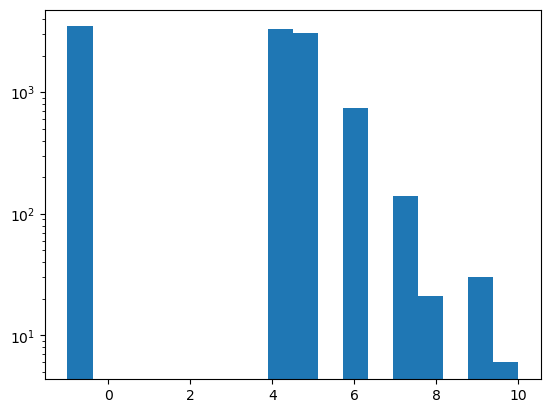

In [13]:
plt.figure()
plt.hist(res['path_length'], bins=18)
plt.yscale('log')
plt.show()


In [35]:
res2 = {'output':[], 'n_ancestors':[]}
for output in output_names: 
    n_ancestors = len(nx.ancestors(G, output))
    res2['output'].append(output)
    res2['n_ancestors'].append(n_ancestors)
res2 = pd.DataFrame(res2)
res2.head() 


,output,n_ancestors
0,GENE__GNPDA1,1
1,GENE__CDH3,5600
2,GENE__HDAC6,5600
3,GENE__PARP2,1
4,GENE__MAMLD1,1


In [48]:
isolates = res2[res2['n_ancestors'] <= 1].output.tolist() # only includes output and the RNA (function node) - no other connections 
isolates = [x.split('__')[1] for x in isolates]
len(isolates), 978


(413, 978)

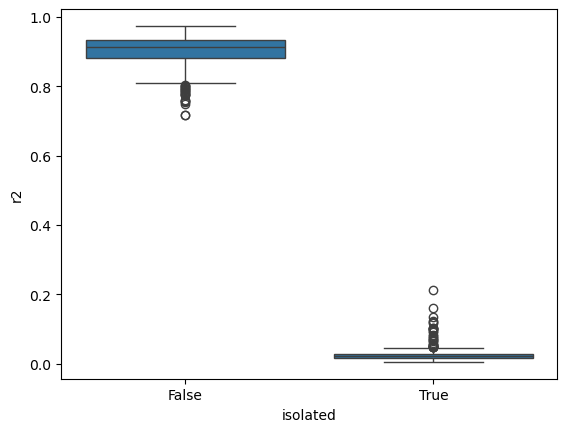

In [46]:
OUT_DIR = PRETRAIN_DIR / "eval_train"
per_gene = pd.read_csv(OUT_DIR / "per_gene_train_metrics.csv")
per_gene = per_gene.groupby('gene')[['r2']].mean().reset_index()
per_gene = per_gene.assign(isolated = lambda x: x.gene.isin(isolates))

import seaborn as sbn

plt.figure() 
sbn.boxplot(x='isolated', y='r2', data=per_gene)
plt.show()


In [47]:
per_gene[lambda x: ~x.isolated].r2.mean() 


0.9035049543549529

In [49]:
per_gene[lambda x: ~x.isolated].r2.quantile((0.05, 0.95))

0.05    0.815467
0.95    0.955154
Name: r2, dtype: float64

In [33]:
import umap
from torch_geometric.nn import Node2Vec


def node2vec_layout(
    A,
    dim=128,
    n_components=4,
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1.0,
    q=1.0,
    epochs=50,
    batch_size=128,
    lr=0.01,
    device=None,
    seed=0,
):
    """Learn node embeddings via Node2Vec, then reduce with UMAP.

    Parameters
    ----------
    A : array-like or torch.Tensor, shape [N, N]
        (Possibly weighted) adjacency matrix. Non-zero entries are
        treated as directed edges.
    dim : int
        Node2Vec embedding dimension.
    n_components : int
        Output dimension after UMAP.

    Returns
    -------
    u : np.ndarray, shape [N, n_components]
        UMAP projection of the Node2Vec embeddings.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    A = torch.as_tensor(np.asarray(A), dtype=torch.float32)
    N = A.shape[0]

    edge_index = A.nonzero(as_tuple=False).t().contiguous().to(device)

    torch.manual_seed(seed)
    np.random.seed(seed)

    model = Node2Vec(
        edge_index,
        embedding_dim=dim,
        walk_length=walk_length,
        context_size=context_size,
        walks_per_node=walks_per_node,
        num_negative_samples=num_negative_samples,
        p=p,
        q=q,
        num_nodes=N,
        sparse=True,
    ).to(device)

    loader = model.loader(batch_size=batch_size, shuffle=True, num_workers=0)
    optimizer = torch.optim.SparseAdam(list(model.parameters()), lr=lr)

    model.train()
    for epoch in range(epochs):
        total_loss = 0.0
        for pos_rw, neg_rw in loader:
            optimizer.zero_grad()
            loss = model.loss(pos_rw.to(device), neg_rw.to(device))
            loss.backward()
            optimizer.step()
            total_loss += float(loss)
        if (epoch + 1) % max(1, epochs // 10) == 0 or epoch == 0:
            print(f"[node2vec] epoch {epoch + 1:3d}/{epochs}  loss={total_loss / len(loader):.4f}")

    model.eval()
    with torch.no_grad():
        z = model.embedding.weight.detach().cpu().numpy()

    reducer = umap.UMAP(n_components=n_components, random_state=seed)
    u = reducer.fit_transform(z)
    return u


/home/exacloud/gscratch/mcweeney_lab/evans/external/miniforge3/envs/lincs-gsnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [34]:
A = nx.adjacency_matrix(G).todense()
z = node2vec_layout(A)

ImportError: 'Node2Vec' requires either the 'pyg-lib' or 'torch-cluster' package

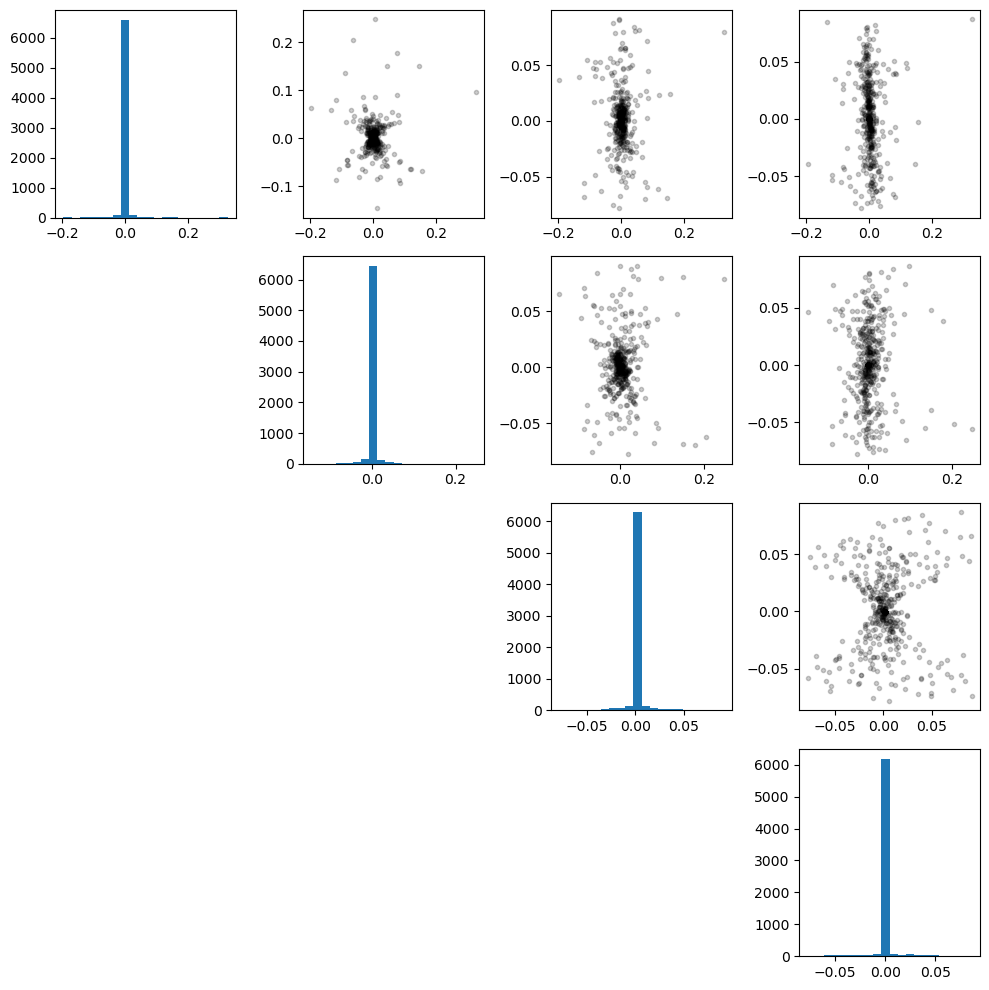

In [37]:
f,axes = plt.subplots(n_components, n_components, figsize=(10,10))

for i in range(n_components): 
    for j in range(n_components): 
        if i == j: 
            axes[i, j].hist(z[:,i], bins=20)
        elif i < j: 
            axes[i, j].plot(z[:,i], z[:,j], 'k.', alpha=0.1)
        else: 
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()
